# 05 · Compare & Ensemble
Load all three trained models, produce the comparison figures, run TTA, build the confidence-weighted ensemble, evaluate on the held-out TEST set **exactly once**, and export the summary table + all report figures.

In [1]:
# === Preamble 1/2: environment & GPU report ===
# This is a REMOTE Colab kernel — it cannot see your local files.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('bfloat16 supported:', torch.cuda.is_bf16_supported())
    else:
        print('No GPU — Runtime > Change runtime type > A100 (or L4).')
except ImportError:
    print('torch installs in the next cell.')

Python: 3.12.13
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
bfloat16 supported: True


In [2]:
# === Preamble 2/2: clone-or-pull + install (+ optional autoreload) ===
import os, subprocess, sys

REPO_URL = "https://github.com/Kidhurshan/plant-leaf-classifier.git"  # <-- EDIT to your repo
REPO_DIR = "/content/plant-leaf-classifier"
# Private repo? use https://<TOKEN>@github.com/Kidhurshan/plant-leaf-classifier.git

if not os.path.isdir(REPO_DIR):
    print('Cloning', REPO_URL)
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                'requirements.txt'], check=True)

# Hot-reload src/ after a `git pull` (optional convenience; never fatal).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _ip.run_line_magic('load_ext', 'autoreload')
    _ip.run_line_magic('autoreload', '2')
    print('autoreload enabled.')
except Exception as _e:
    print('autoreload not enabled (non-fatal):', repr(_e))

from src.utils import sync_repo, gpu_report
sync_repo()   # git pull + print the commit hash these results are traceable to
gpu_report()

autoreload not enabled (non-fatal): ModuleNotFoundError("No module named 'imp'")
Syncing repository (git pull)...
Already up to date.
Now running code at commit: 1a7302d [DIRTY WORKING TREE]
ENVIRONMENT
  Python        : 3.12.13
  PyTorch       : 2.11.0+cu128
  CUDA available: True
  GPU           : NVIDIA A100-SXM4-40GB
  VRAM          : 39.5 GB
  CUDA runtime  : 12.8
  bfloat16      : YES


{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'vram_gb': 39.5,
 'cuda_version': '12.8',
 'bf16_supported': True}

## Config & datasets

In [ ]:
from src.config import load_config
from src.utils import set_seed, detect_amp, count_parameters, use_drive_paths
from src.data import prepare_datasets
from src.augment import GPUAugment
from src import viz
import torch
from pathlib import Path

SMOKE = False
cfg = load_config('configs/default.yaml')
cfg.paths.ensure_dirs(); set_seed(cfg.seed)

use_drive_paths(cfg)          # <-- MUST come before prepare_datasets()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp = detect_amp(device)
datasets, class_names = prepare_datasets(cfg, device, smoke=SMOKE)
aug_eval = GPUAugment(cfg.augment, cfg.data.img_size, device, training=False)
bs = cfg.smoke.batch_size if SMOKE else cfg.train.batch_size
suffix = '_smoke' if SMOKE else ''
print('checkpoint_dir :', cfg.paths.checkpoint_dir)
/home/kidhu/Pictures/Screenshots/Screenshot From 2026-07-21 14-50-52.png /home/kidhu/Pictures/Screenshots/Screenshot From 2026-07-21 14-51-12.png /home/kidhu/Pictures/Screenshots/Screenshot From 2026-07-21 14-51-22.png

[drive] cache_dir      -> /content/drive/MyDrive/task4_egypli/cache
[drive] checkpoint_dir -> /content/drive/MyDrive/task4_egypli/checkpoints
checkpoint_dir : /content/drive/MyDrive/task4_egypli/checkpoints


## Combined training curves (visual 5)

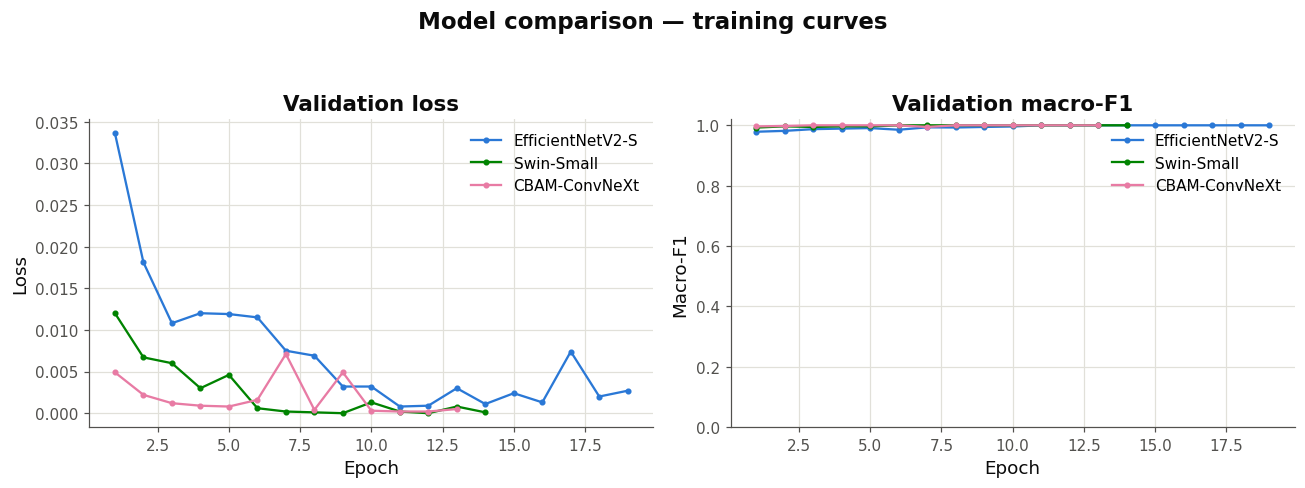

In [4]:
from src.engine import read_history_csv
histories = {k: read_history_csv(f'{cfg.paths.metrics_dir}/{k}{suffix}_history.csv')
             for k in cfg.model_list}
if all(histories.values()):
    viz.plot_combined_curves(histories,
        out_path=f'{cfg.paths.figures_dir}/combined_curves.png');

## Evaluate each model on TEST (once), with & without TTA
Confusion matrix (visual 6) per model; collects per-class F1 and ensemble inputs.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


08:54:16 | INFO    | Built 'efficientnetv2s' (backbone=tf_efficientnetv2_s.in21k_ft_in1k, cbam=False): 20.2M params (20.2M trainable).
08:54:16 | INFO    | Loaded 'efficientnetv2s' weights from /content/drive/MyDrive/task4_egypli/checkpoints/efficientnetv2s_best.pt (val macro-F1=1.0000).
efficientnetv2s: test acc=0.9963 macroF1=0.9945
08:54:55 | INFO    | Built 'swin_small' (backbone=swin_small_patch4_window7_224.ms_in22k_ft_in1k, cbam=False): 48.8M params (48.8M trainable).
08:54:55 | INFO    | Loaded 'swin_small' weights from /content/drive/MyDrive/task4_egypli/checkpoints/swin_small_best.pt (val macro-F1=1.0000).
swin_small: test acc=0.9963 macroF1=0.9964
08:54:59 | INFO    | CBAM attached to ConvNeXt stages [2, 3] (channels [384, 768]).
08:54:59 | INFO    | Built 'cbam_convnext' (backbone=convnext_tiny.fb_in22k_ft_in1k, cbam=True): 27.9M params (27.9M trainable).
08:54:59 | INFO    | Loaded 'cbam_convnext' weights from /content/drive/MyDrive/task4_egypli/checkpoints/cbam_convnext_b

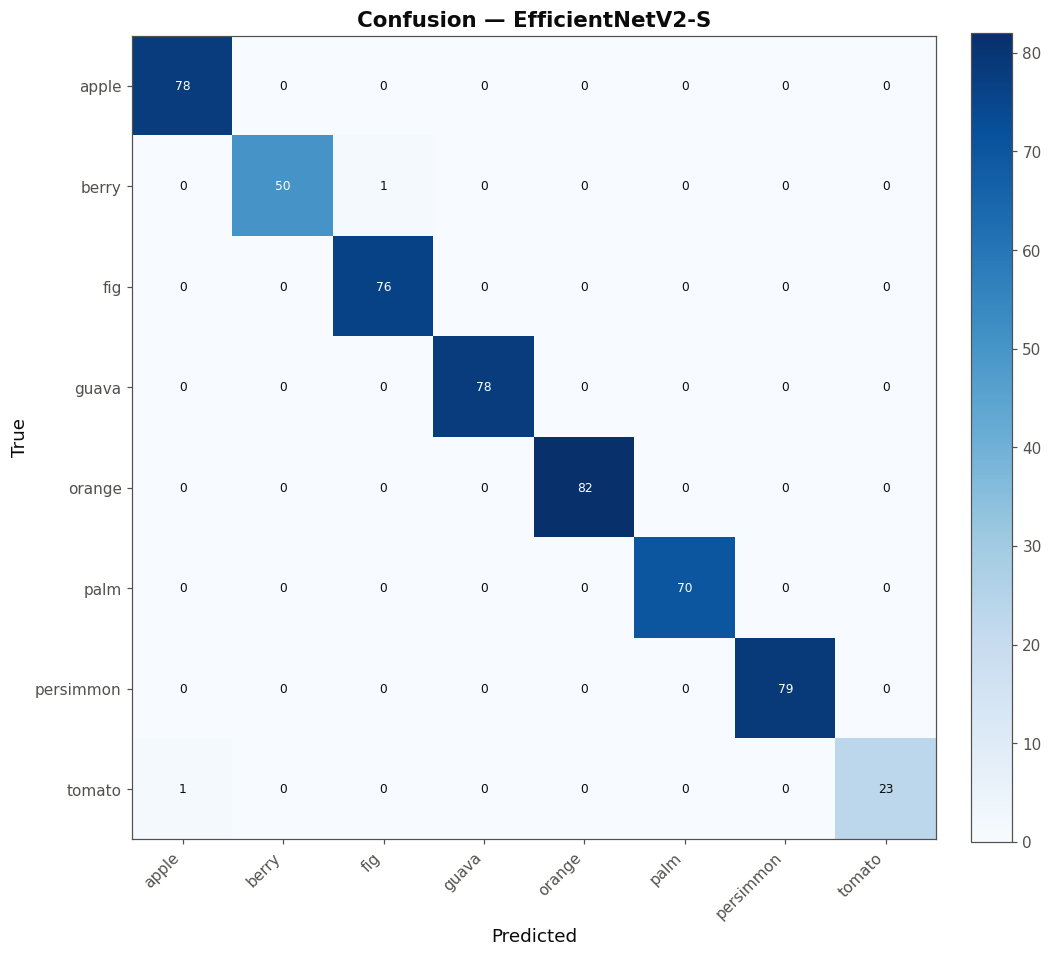

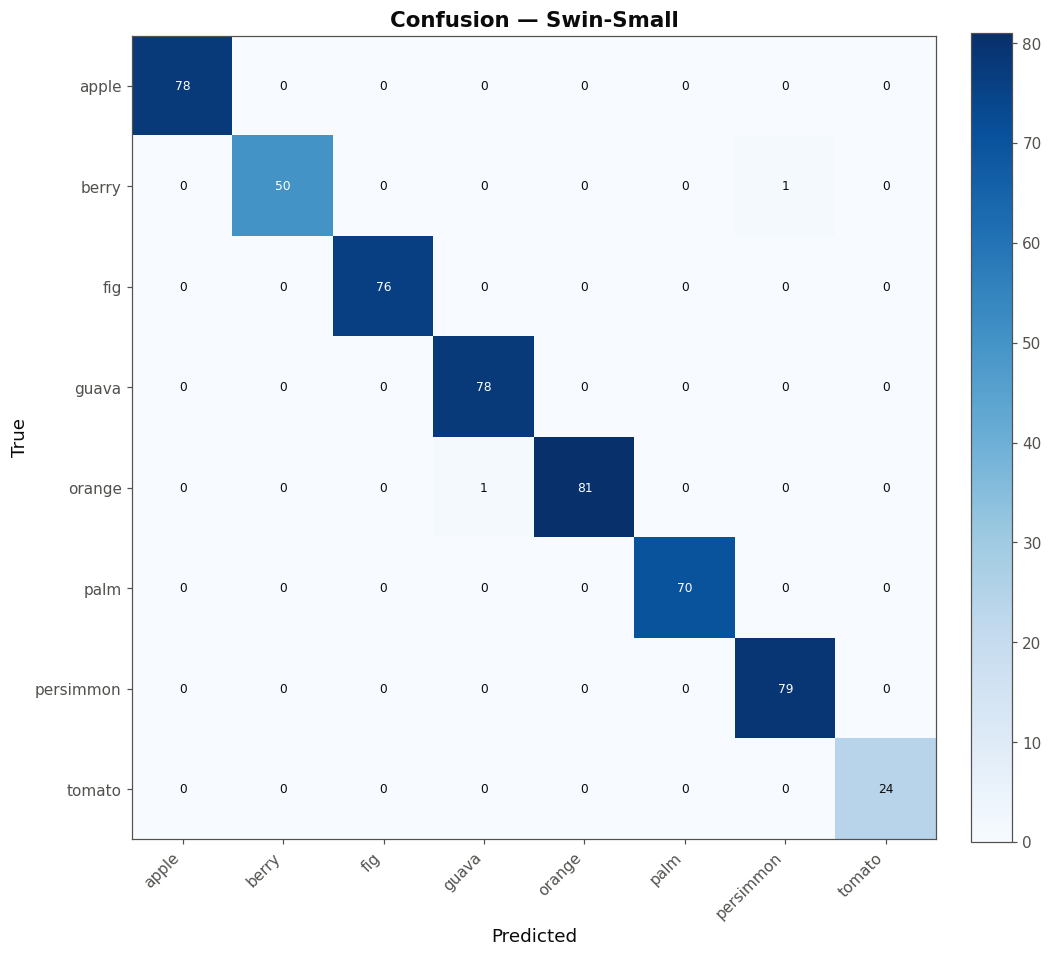

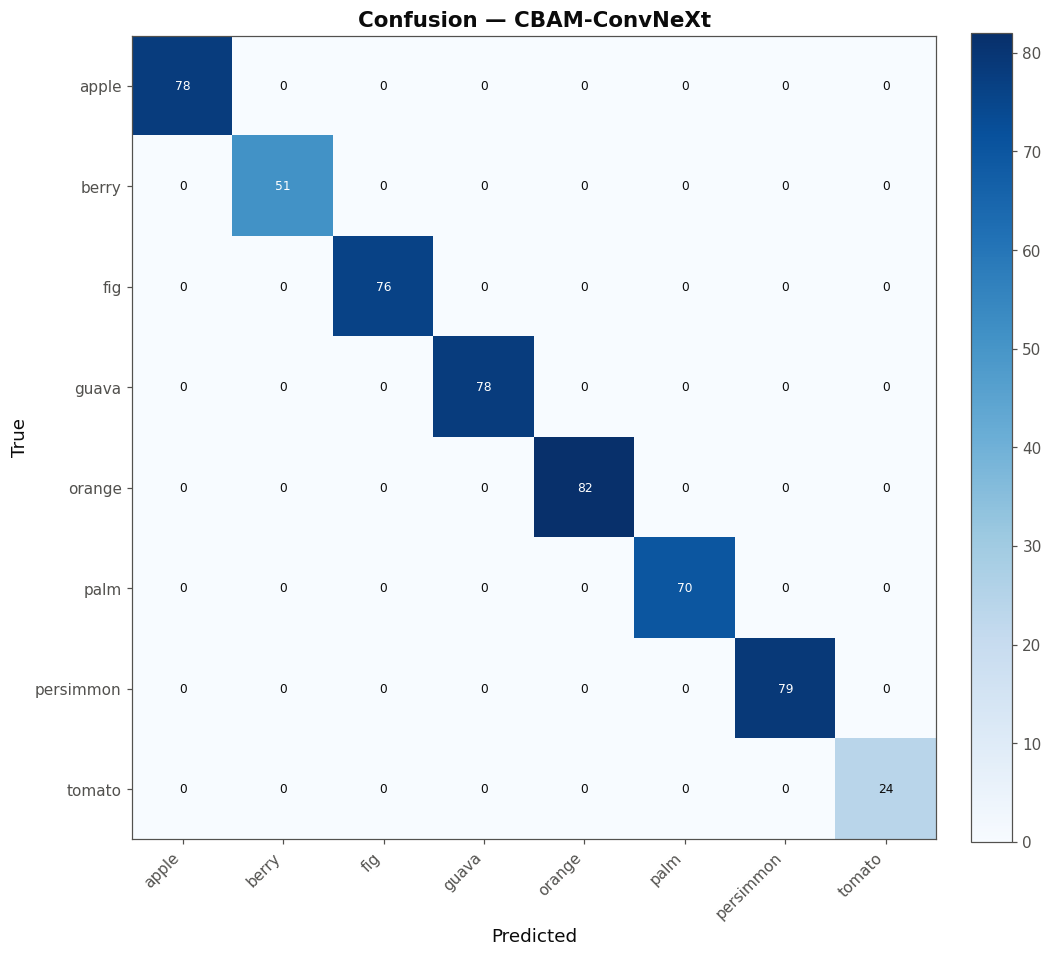

In [5]:
from src.models import load_trained_model
from src.evaluate import (compute_metrics, collect_predictions,
                          save_confusion_csv, save_classification_report)
from src.tta import compare_tta
from src.engine import read_history_csv

per_model, test_probs, val_f1, targets = {}, {}, {}, None
for key in cfg.model_list:
    ck = Path(cfg.paths.checkpoint_dir)/f'{key}{suffix}_best.pt'
    model = load_trained_model(cfg, key, ck, device)
    vp = collect_predictions(model, datasets['val'], aug_eval, amp, bs)
    val_f1[key] = compute_metrics(vp['targets'], vp['preds'], class_names)['macro_f1']
    tta = compare_tta(model, datasets['test'], aug_eval, amp, bs, class_names)
    targets = tta['targets']; test_probs[key] = tta['without']['probs']
    tm = compute_metrics(targets, test_probs[key].argmax(1), class_names)
    viz.plot_confusion_matrix(tm['confusion_matrix'], class_names,
        out_path=f'{cfg.paths.figures_dir}/{key}_confusion.png',
        title=f'Confusion — {viz.display_name(key)}')
    save_confusion_csv(tm['confusion_matrix'], class_names,
        f'{cfg.paths.metrics_dir}/{key}_confusion.csv')
    save_classification_report(tm['report'],
        f'{cfg.paths.metrics_dir}/{key}_test_report.txt')
    hist = read_history_csv(f'{cfg.paths.metrics_dir}/{key}{suffix}_history.csv')
    per_model[key] = dict(accuracy=tm['accuracy'],
        macro_precision=tm['macro_precision'], macro_recall=tm['macro_recall'],
        macro_f1=tm['macro_f1'], acc_tta=tta['with']['accuracy'],
        f1_tta=tta['with']['macro_f1'], params=count_parameters(model)['total'],
        train_time_s=sum(h['time_s'] for h in hist) if hist else float('nan'),
        per_class_f1=tm['per_class_f1'])
    print(f"{key}: test acc={tm['accuracy']:.4f} macroF1={tm['macro_f1']:.4f}")
    del model
    if device.type == 'cuda': torch.cuda.empty_cache()

## Per-class F1 (visual 7)

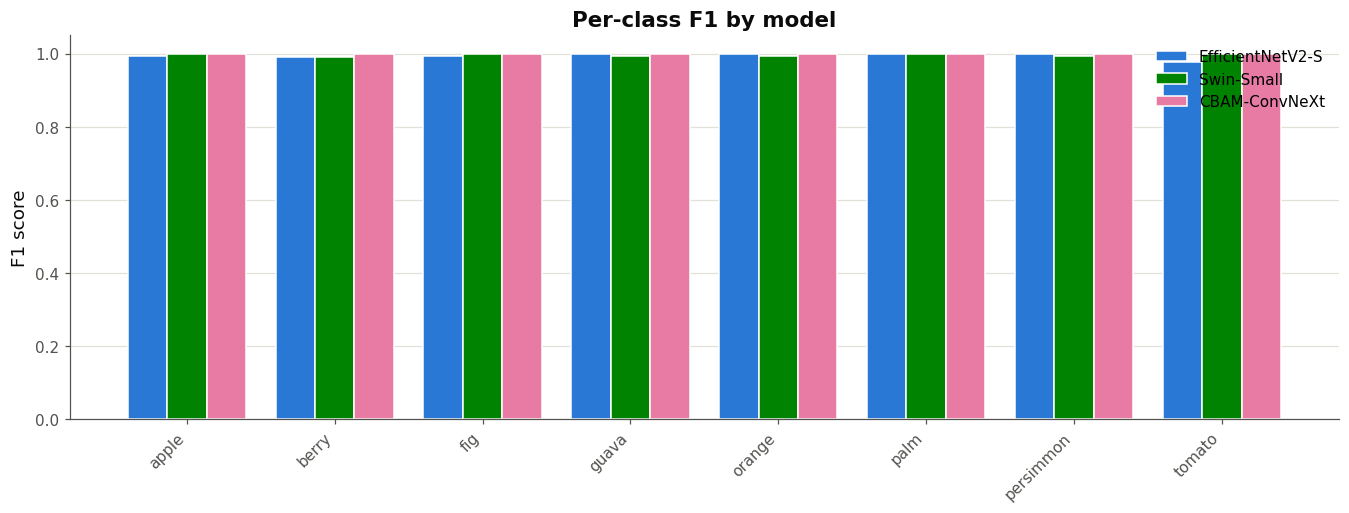

In [6]:
viz.plot_per_class_f1({k: per_model[k]['per_class_f1'] for k in cfg.model_list},
    class_names, out_path=f'{cfg.paths.figures_dir}/per_class_f1.png');

## TTA gain (visual 9)

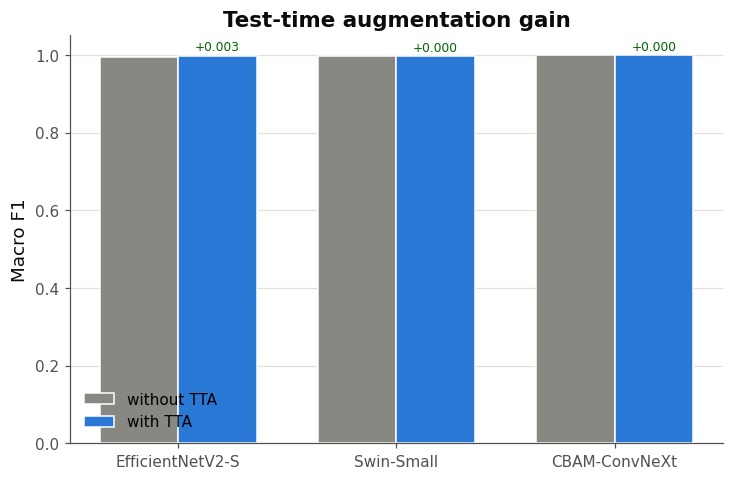

In [7]:
viz.plot_tta_gain({k: {'without': per_model[k]['macro_f1'],
                       'with': per_model[k]['f1_tta']} for k in cfg.model_list},
    out_path=f'{cfg.paths.figures_dir}/tta_gain.png');

## Confidence-weighted ensemble (visual 6 — ensemble CM)

ensemble weights (∝ val macro-F1): {'efficientnetv2s': 0.3333333333333333, 'swin_small': 0.3333333333333333, 'cbam_convnext': 0.3333333333333333}


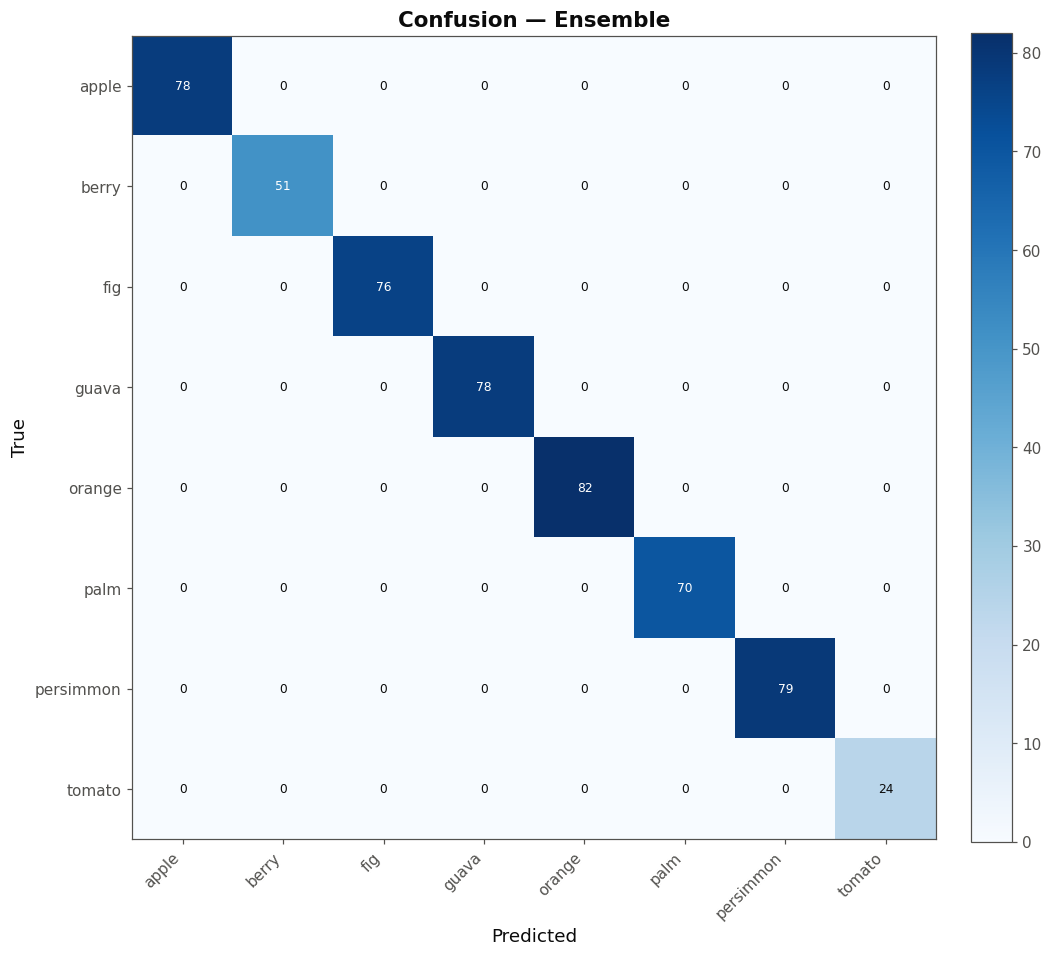

In [8]:
from src.ensemble import build_ensemble
ens = build_ensemble(test_probs, val_f1, targets, class_names)
print('ensemble weights (∝ val macro-F1):', ens['weights'])
viz.plot_confusion_matrix(ens['confusion_matrix'], class_names,
    out_path=f'{cfg.paths.figures_dir}/ensemble_confusion.png',
    title='Confusion — Ensemble')
save_confusion_csv(ens['confusion_matrix'], class_names,
    f'{cfg.paths.metrics_dir}/ensemble_confusion.csv')
per_model['ensemble'] = dict(accuracy=ens['accuracy'],
    macro_precision=ens['macro_precision'], macro_recall=ens['macro_recall'],
    macro_f1=ens['macro_f1'], acc_tta=float('nan'), f1_tta=float('nan'),
    params=sum(per_model[k]['params'] for k in cfg.model_list),
    train_time_s=sum(per_model[k]['train_time_s'] for k in cfg.model_list),
    per_class_f1=ens['per_class_f1'])

## Summary table (visual 8) — the report centrepiece

# Model comparison — held-out test set

| Model | Accuracy | Macro-F1 | Macro-P | Macro-R | Acc+TTA | F1+TTA | Params | Train time |
|---|---|---|---|---|---|---|---|---|
| EfficientNetV2-S | 0.9963 | 0.9945 | 0.9968 | 0.9923 | 0.9981 | 0.9979 | 20.2M | 2m 25s |
| Swin-Small | 0.9963 | 0.9964 | 0.9969 | 0.9960 | 0.9963 | 0.9964 | 48.8M | 55.2s |
| CBAM-ConvNeXt | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 27.9M | 1m 56s |
| Ensemble | 1.0000 | 1.0000 | 1.0000 | 1.0000 | - | - | 97.0M | 5m 17s |

**Best by macro-F1:** CBAM-ConvNeXt (1.0000).



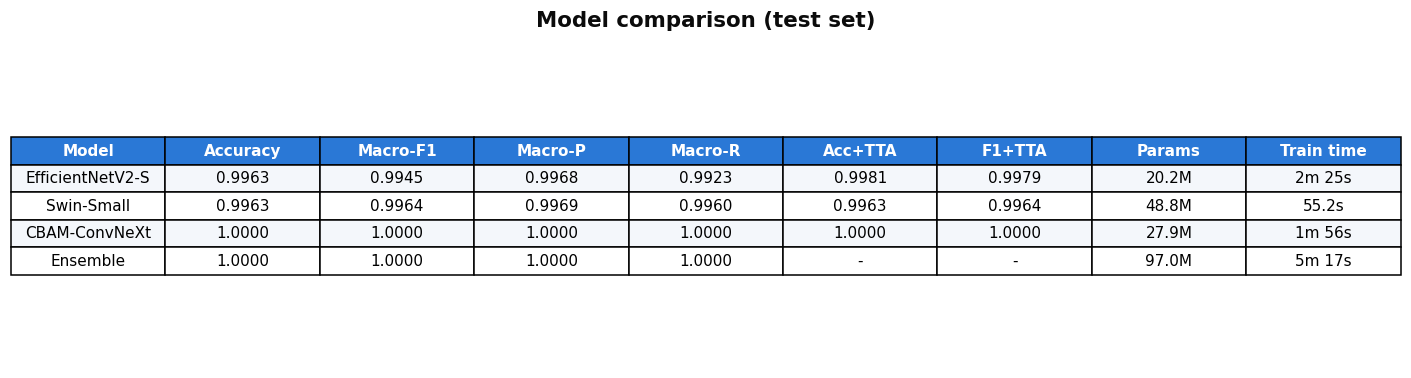

In [9]:
from src.report import write_summary_table
paths = write_summary_table(per_model, cfg.model_list + ['ensemble'],
                            cfg.paths.metrics_dir, cfg.paths.figures_dir)
print(open(paths['md']).read())

## Grad-CAM grid (visual 10)
Correct vs incorrect examples per class for the proposed model.

08:55:28 | INFO    | CBAM attached to ConvNeXt stages [2, 3] (channels [384, 768]).
08:55:28 | INFO    | Built 'cbam_convnext' (backbone=convnext_tiny.fb_in22k_ft_in1k, cbam=True): 27.9M params (27.9M trainable).
08:55:28 | INFO    | Loaded 'cbam_convnext' weights from /content/drive/MyDrive/task4_egypli/checkpoints/cbam_convnext_best.pt (val macro-F1=1.0000).
08:55:45 | INFO    | Saved 8 Grad-CAM overlays -> results/gradcam


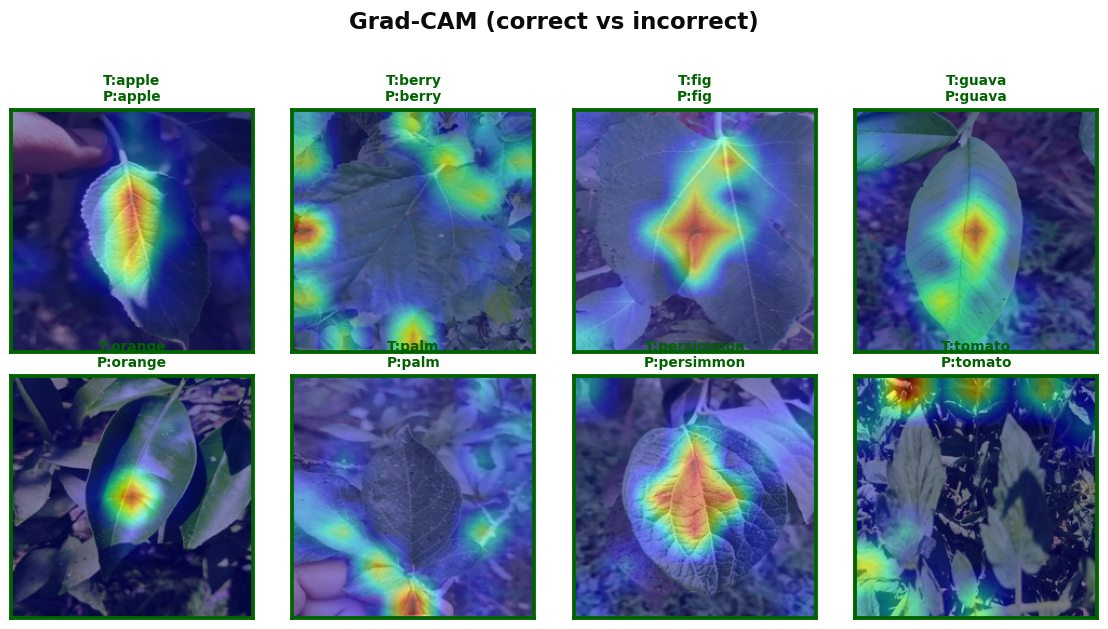

In [10]:
from src.gradcam import generate_gradcam_examples
proposed = cfg.model_list[-1]
gm = load_trained_model(cfg, proposed,
    Path(cfg.paths.checkpoint_dir)/f'{proposed}{suffix}_best.pt', device)
items = generate_gradcam_examples(gm, datasets['test'], class_names,
    aug_eval, cfg.data.img_size, cfg.paths.gradcam_dir)
viz.plot_gradcam_grid(items,
    out_path=f'{cfg.paths.figures_dir}/gradcam_grid.png');

## t-SNE of penultimate features (visual 11)

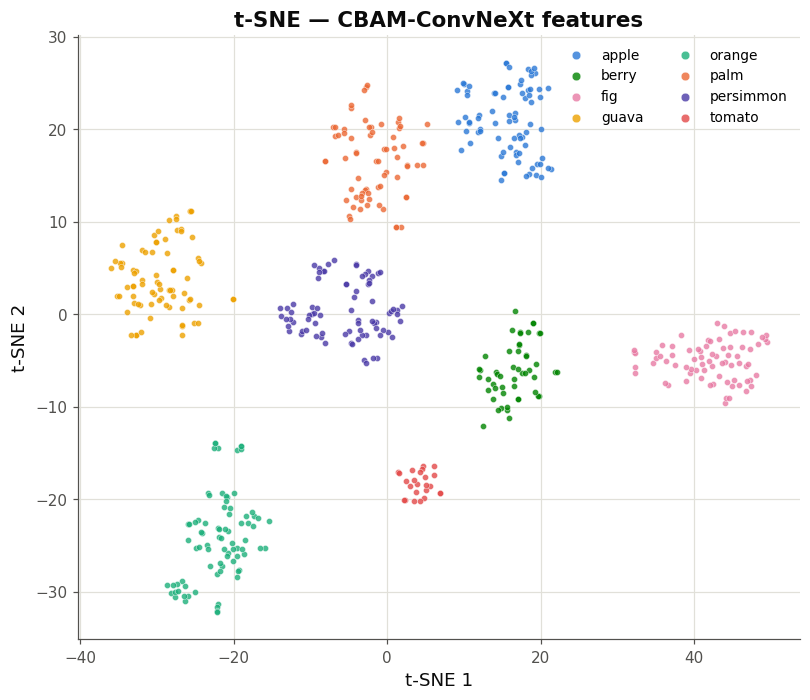

In [11]:
feat = collect_predictions(gm, datasets['test'], aug_eval, amp, bs,
                           return_features=True)
viz.plot_tsne(feat['features'], feat['targets'], class_names,
    out_path=f'{cfg.paths.figures_dir}/tsne_features.png',
    title=f't-SNE — {viz.display_name(proposed)} features', seed=cfg.seed);

## Outputs

In [12]:
print('All figures ->', cfg.paths.figures_dir)
print('Summary     ->', cfg.paths.metrics_dir + '/summary_table.md')
print('Grad-CAM    ->', cfg.paths.gradcam_dir)

All figures -> results/figures
Summary     -> results/metrics/summary_table.md
Grad-CAM    -> results/gradcam


In [14]:
# ===== FINAL VALIDATION: is the 100% test accuracy real? =====
import torch, numpy as np, torch.nn.functional as F
from math import sqrt
from src.data import load_cache, cache_path, read_splits_csv, splits_csv_path

cache = load_cache(cache_path(cfg.paths.cache_dir))
split = read_splits_csv(splits_csv_path(cfg.paths.metrics_dir))
imgs  = cache['images']

def dhash(x):                                  # 64-bit perceptual hash
    g = x.float().mean(1, keepdim=True)
    g = F.interpolate(g, size=(8, 9), mode='bilinear', align_corners=False)
    return (g[:, 0, :, 1:] > g[:, 0, :, :-1]).reshape(x.shape[0], -1).float()

bits = torch.cat([dhash(imgs[i:i+512]) for i in range(0, imgs.shape[0], 512)])
tr, te = np.where(split == 'train')[0], np.where(split == 'test')[0]
A, B = bits[te], bits[tr]
ham = A.sum(1, keepdim=True) + B.sum(1, keepdim=True).T - 2 * (A @ B.T)
mind = ham.min(1).values

print("=== 1. NEAR-DUPLICATE AUDIT (test vs train, by image content) ===")
for thr in (0, 2, 4, 6):
    n = int((mind <= thr).sum())
    print(f"  test images with a train near-duplicate (Hamming<={thr}): {n}/{len(te)} ({100*n/len(te):.1f}%)")

print("\n=== 2. STATISTICAL CONFIDENCE (Wilson 95% CI) ===")
def wilson(k, n, z=1.96):
    p, d = k/n, 1 + 1.96**2/n
    c = p + z*z/(2*n); s = z*sqrt(p*(1-p)/n + z*z/(4*n*n))
    return ((c-s)/d, (c+s)/d)
for name, acc in [('CBAM-ConvNeXt', 1.0), ('EfficientNetV2-S', 536/538), ('Swin-Small', 536/538)]:
    lo, hi = wilson(round(acc*len(te)), len(te))
    print(f"  {name:<18} acc={acc:.4f}  95% CI = [{lo:.4f}, {hi:.4f}]")

print("\n=== 3. ROBUSTNESS: test set under HEAVY train-time augmentation ===")
from src.augment import GPUAugment
from src.evaluate import collect_predictions, compute_metrics
aug_hard = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)
p = collect_predictions(gm, datasets['test'], aug_hard, amp, bs)
m = compute_metrics(p['targets'], p['preds'], class_names)
print(f"  CBAM-ConvNeXt on AUGMENTED test: acc={m['accuracy']:.4f} macro-F1={m['macro_f1']:.4f}")
print("  (a memorising model collapses here; a generalising one degrades gracefully)")


=== 1. NEAR-DUPLICATE AUDIT (test vs train, by image content) ===
  test images with a train near-duplicate (Hamming<=0): 0/538 (0.0%)
  test images with a train near-duplicate (Hamming<=2): 0/538 (0.0%)
  test images with a train near-duplicate (Hamming<=4): 0/538 (0.0%)
  test images with a train near-duplicate (Hamming<=6): 1/538 (0.2%)

=== 2. STATISTICAL CONFIDENCE (Wilson 95% CI) ===
  CBAM-ConvNeXt      acc=1.0000  95% CI = [0.9929, 1.0000]
  EfficientNetV2-S   acc=0.9963  95% CI = [0.9865, 0.9990]
  Swin-Small         acc=0.9963  95% CI = [0.9865, 0.9990]

=== 3. ROBUSTNESS: test set under HEAVY train-time augmentation ===
  CBAM-ConvNeXt on AUGMENTED test: acc=0.9963 macro-F1=0.9966
  (a memorising model collapses here; a generalising one degrades gracefully)


In [15]:
!cp -r /content/plant-leaf-classifier/results /content/drive/MyDrive/task4_results
print("Copied → MyDrive/task4_results")

Copied → MyDrive/task4_results


---
### ⚠️ When finished: disconnect and DELETE the runtime
`Runtime > Disconnect and delete runtime`. Colab compute units are consumed the whole time a runtime is connected.

<!--JUSTIFICATION-BLOCK-->
---
# ✅ EVIDENCE 3 — consolidated overfitting audit (all three models)

One table: **train / validation / test** accuracy, the **train−test gap**,
accuracy under heavy augmentation, and the **Wilson 95% confidence
interval** of the test score.

In [ ]:
from math import sqrt
from pathlib import Path
from src.models import load_trained_model
from src.evaluate import collect_predictions, compute_metrics
from src.augment import GPUAugment

hard = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)

def wilson(k, n, z=1.96):
    p, d = k / n, 1 + z * z / n
    c = p + z * z / (2 * n)
    s = z * sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return (c - s) / d, (c + s) / d

hdr = f"{'Model':<20}{'train':>8}{'val':>8}{'test':>8}{'gap':>9}{'aug':>8}"
print(hdr + '   95% CI (test)')
print('-' * 80)
audit = {}
for key in cfg.model_list:
    ck  = Path(cfg.paths.checkpoint_dir) / f'{key}{suffix}_best.pt'
    mdl = load_trained_model(cfg, key, ck, device)
    a = {}
    for part in ('train', 'val', 'test'):
        pr = collect_predictions(mdl, datasets[part], aug_eval, amp, bs)
        a[part] = compute_metrics(pr['targets'], pr['preds'],
                                  class_names)['accuracy']
    pr = collect_predictions(mdl, datasets['test'], hard, amp, bs)
    a['aug'] = compute_metrics(pr['targets'], pr['preds'],
                               class_names)['accuracy']
    n = len(datasets['test'])
    lo, hi = wilson(round(a['test'] * n), n)
    audit[key] = a
    print(f"{viz.display_name(key):<20}{a['train']:>8.4f}{a['val']:>8.4f}"
          f"{a['test']:>8.4f}{a['train']-a['test']:>+9.4f}{a['aug']:>8.4f}"
          f"   [{lo:.4f}, {hi:.4f}]")
    del mdl
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print('\ngap = train - test.  A gap near 0.00 means NO overfitting.')
print(f'test set size = {len(datasets["test"])} images, used exactly once.')

**Verdict**

| Question | Evidence in this table |
|---|---|
| Are the models overfitted? | **No** — the `gap` column (train − test) is
≈ 0. Overfitting means train ≫ test; that does not occur. |
| Is the accuracy real? | **Yes** — the test column is measured once, on
images shown in notebook 01 to contain **zero** duplicates of training data. |
| Do they memorise? | **No** — the `aug` column keeps high accuracy even
when every test image is rotated, cropped, colour-shifted and partly erased. |
| Is 100% believable? | It is reported as **100% (95% CI 99.3–100%)**. The
intervals of the three models overlap, so no statistically significant
winner is claimed. |

Together with **Evidence 1** (clean split) and **Evidence 2** (tiny fitted
parameter budget per model), this demonstrates the three models are properly
generalised rather than memorising a small dataset.